
# Lab1_3: PDE

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filename3 = 'Laplace_df_3.png'
filename2 = 'Laplace_df_2.png'
filename4 = 'Laplace_df_4.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



#### **Exercise 1**: Lab1_3: finite-differences with tolerance **Jacobi method**


SOlve the Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$).
2. Do a plot of the field $u(x,y)$ for a tolerance of $\text{tol}=10^{-3}$. Explaint in words the strategy.
3. Compare with Fourier serie. How many terms in the fourier serie are necesary to obtaind a $\text{tol}=10^{-3}$.

#### **Exercise 2**: finite-differences for oppen boundaries

Solve analytically and numerically the **Laplace's equation** for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x) = $u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* u(0,y)=0
* u(L,y)=0
* u(x,$\infty$)=0


To solve numerically the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

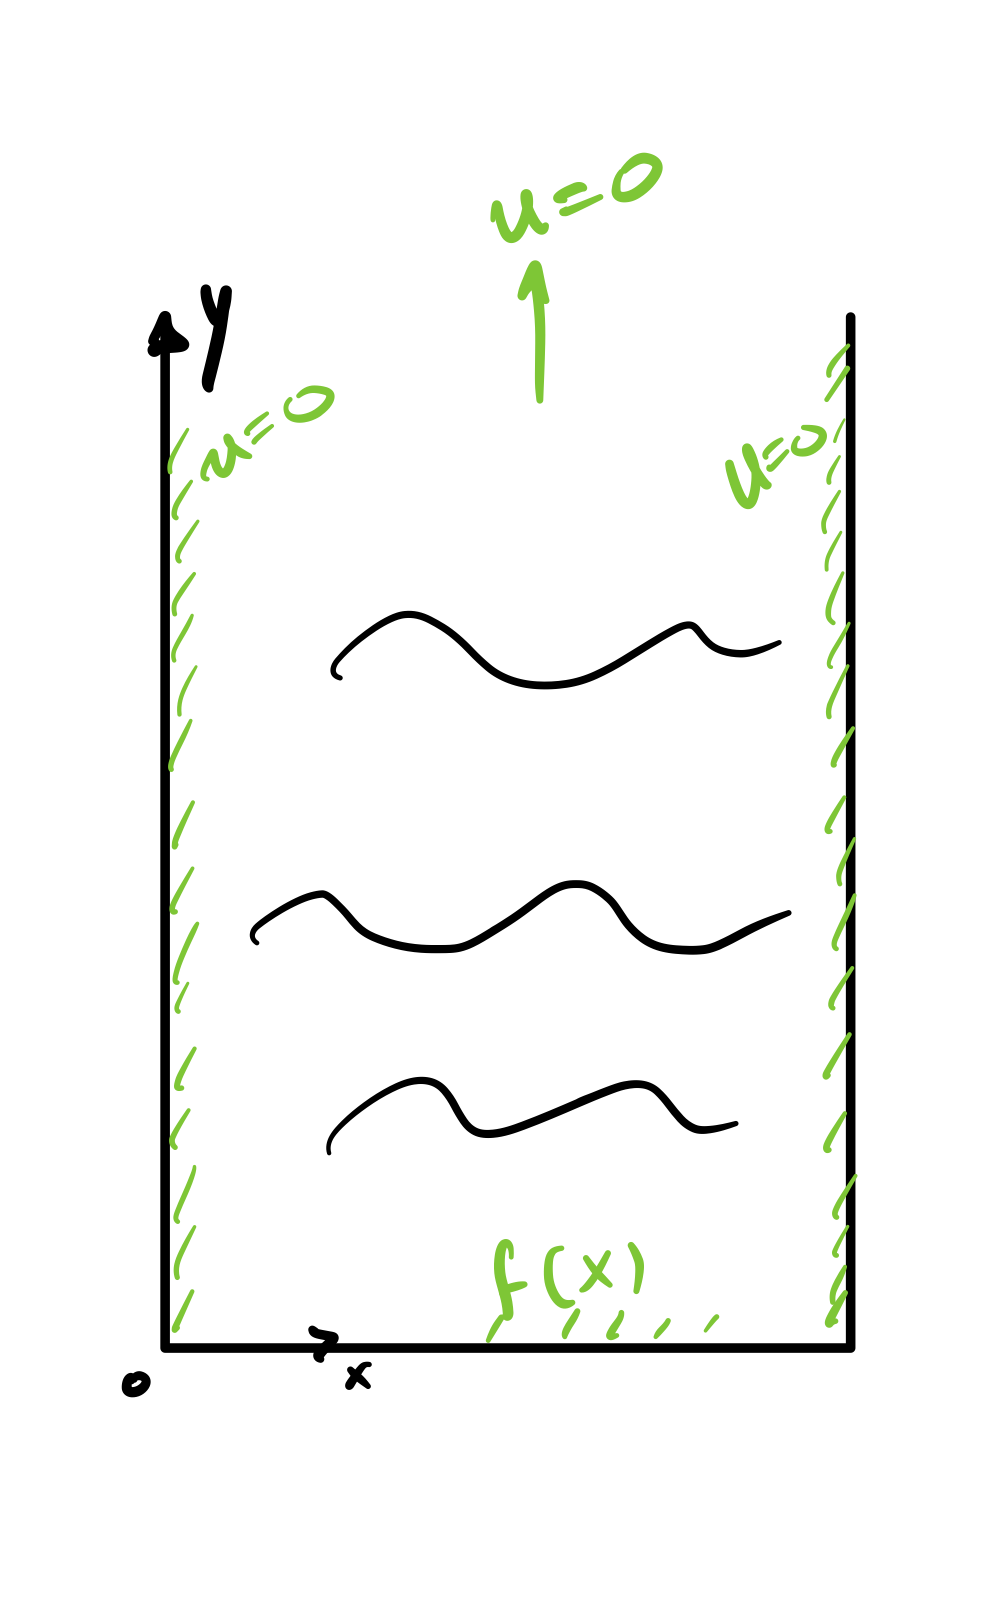

In [6]:
from IPython.display import Image
Image(filename=path+filename4, width=300)

# Solución

## Primer punto.
Vamos a programar en Jacobi (esta es la relación matricial) la solución de la ecuación de Laplace dada por diferencia finitas, se obtiene mediante una expansión en Taylor pa'lante y pa'trás, se despejan la segundas derivadas, se suma e iguala a 0, de ahí se despeja la posición i,j de la matriz de la solución que queremos obtener y se obtiene:
$$
u_{i,j} = \frac{1}{4}\left(u_{i+1,j}+u_{i-1,j}+u_{i,j+1}+u_{i,j-1}\right)
$$
Con esto podemos programar

In [28]:
# Lo primero es crear nuestra función una matriz de 0's donde almacenarla
# Hay que definir un ancho (y alto) de la rejilla que será nuestra función
# El ejercicio plantea un L, pero podemos hacer L = 1 m, por dar un valor
# Dado que no me quiero joder la vida, tomaré 100 píxeles para partir mi solución de 0 a 100, llamémoslo n
n = 100
import numpy as np
u = np.zeros((n,n))
# También vamos a trabajar con C.F. de Dirichlet. Esto es fijar el valor de un borde del cuadrado.
# Para nuestro caso, el valor con y = 0 es t.q. u = 100. El resto de valores ya los tenemos de la definición de u.
u[0,:] = 100
# Con esto listo, pasamos a definir la solución
# Vamos a correr hasta un epsilon
epsilon = 1e-3
# La idea es para cuando la máxima diferencia de entre un valor anterior y el nuevo sea menor que el epsilon
u_new = u.copy()
u_old = u.copy()
count = 0
while True:
    for i in range(1,u.shape[0]-1):
        for j in range(1,u.shape[1]-1):
            u_new[i,j] = .25*(u_old[i+1,j]+u_old[i-1,j]+u_old[i,j+1]+u_old[i,j-1])
    count +=1
    if np.max(np.abs(u_new-u_old))<=epsilon:
        break
    u_old = u_new.copy()
# Nuestra función solución es u_new
# Ahora solo queda graficar
print(f"para una tolerancia de {epsilon:.1e} se hicieron {count} iteraciones")

para una tolerancia de 1.0e-03 se hicieron 5991 iteraciones


No deberian ser tantos términos. son del orden de 100... ERROR

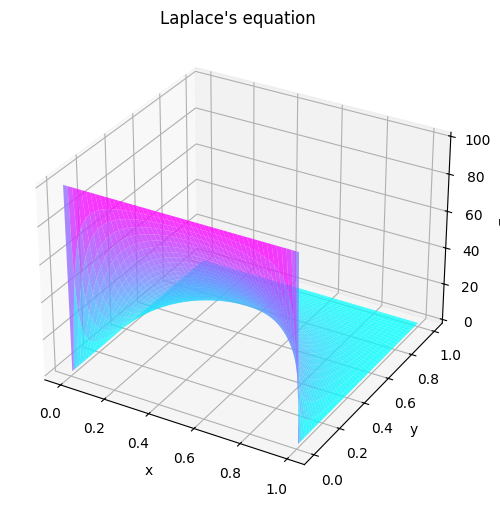

In [29]:
# La forma en que grafica el profe en el Jupyter es muy curiosa, 
# la definición de una función para evaluar en x y y es muy rara,
# poco eficiente y dependiente de que X y Y vayan de 0 a el n (el n definido arriba).
# X y Y son el espacio (el plano en este caso), para el que se define la función
# Son independientes de la función, a menos que las condiciones de frontera lo exijan,
# Para lo que hay que tener cuidado.
# En cualquier caso, definimos nuestro plano (del cuadrante 1 x en [0,1] y y en [0,1])
import matplotlib.pyplot as plt
x = np.linspace(0,1,u.shape[0])
y = x
# lit, el plano
X, Y = np.meshgrid(x,y)

# creamos la figura
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u_new, cmap='cool', alpha=0.8)
# Le damos un título cualquiera
ax.set_title('Laplace\'s equation ')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.show()

Ya por último, debemos comparar con la convergencia de la solución analítica, una serie de Fourier:
$$
u(x,y) = \sum_{n=1,3,5,...}^{\infty}\dfrac{4\,V_0}{n\pi}\sin(\dfrac{n\pi}{L}x)\sinh(\dfrac{n\pi}{L}(L-y))/\sinh(n\pi)
$$

para una tolerancia de 1.0e-03 se hicieron 50 iteraciones


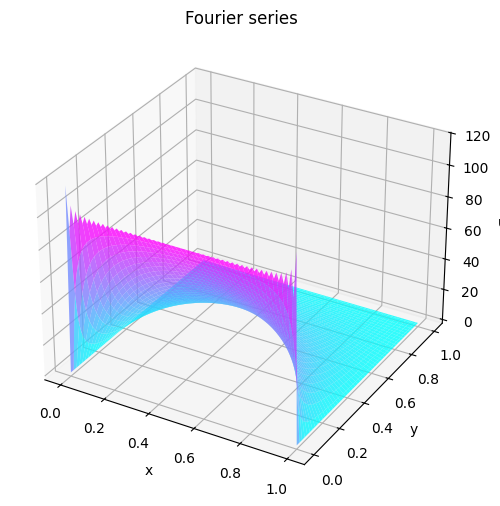

In [33]:
# Creamos nuestro plano
import matplotlib.pyplot as plt
n = 100
x = np.linspace(0,1,n)
y = x
# lit, el plano
X, Y = np.meshgrid(x,y)
# Todo va igual para generar la matriz de iteración
u = np.zeros((n,n))
epsilon = 1e-3
# La idea es para cuando la máxima diferencia de entre un valor anterior y el nuevo sea menor que el epsilon
u_new_ = u.copy()
u_old_ = u.copy()
count = 0
m = 1
while True:
    u_new_ += (100*4)/(m*np.pi)*np.sin(m*np.pi*X)*np.sinh(m*np.pi*(1-Y))/np.sinh(m*np.pi)
    count +=1
    if np.max(np.abs(u_new_-u_old_))<=epsilon:
        break
    u_old_ = u_new_.copy()
    m += 2
# Nuestra función solución es u_new
# Ahora solo queda graficar
print(f"para una tolerancia de {epsilon:.1e} se hicieron {count} iteraciones")
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, u_new_, cmap='cool', alpha=0.8)
# Le damos un título cualquiera
ax.set_title('Fourier series')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('u')
plt.show()

BIEN...NO SON 50 TERMINOS. SON ALREDEDOR DE 11... ES POR LA FORMA QUE CALCULAS EL ERROR. NOTA: 4.5

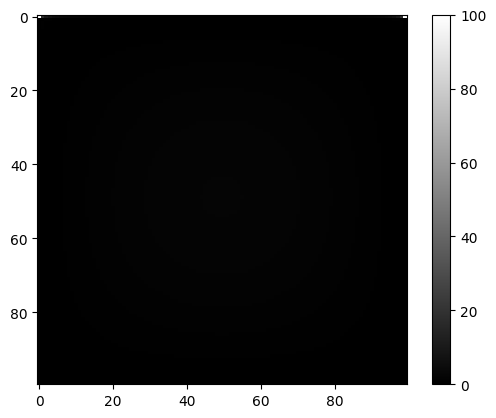

In [ ]:
# converje muchísimo más rápido la serie Fourier, y solo tiene las diferencias en los bordes
plt.imshow(np.abs(u_new_-u_new),  cmap= 'gray')
plt.colorbar()
plt.show()

???????????????????'

## Segundo Punto
Si consideramos que la primera condición es
$$
u(x,0)=u_0  \sin{\left(\frac{2\pi}{L}*x\right)}
$$
Con esto se llega a una solución analítica muy sencilla (la puesta como condicón de frontera).
$$
u(x,y) = u_0 \sin{\left(\frac{2\pi}{L}*x\right)} e^{-\frac{2\pi}{L}y}
$$
Vamos a hacer una numérica, con el código que ya tenemos del punto 1

para una tolerancia de 1.0e-01 se hicieron 199 iteraciones
para una tolerancia de 1.0e-02 se hicieron 940 iteraciones
para una tolerancia de 1.0e-03 se hicieron 2327 iteraciones
para una tolerancia de 1.0e-04 se hicieron 4047 iteraciones
para una tolerancia de 1.0e-05 se hicieron 5864 iteraciones
para una tolerancia de 1.0e-06 se hicieron 7692 iteraciones


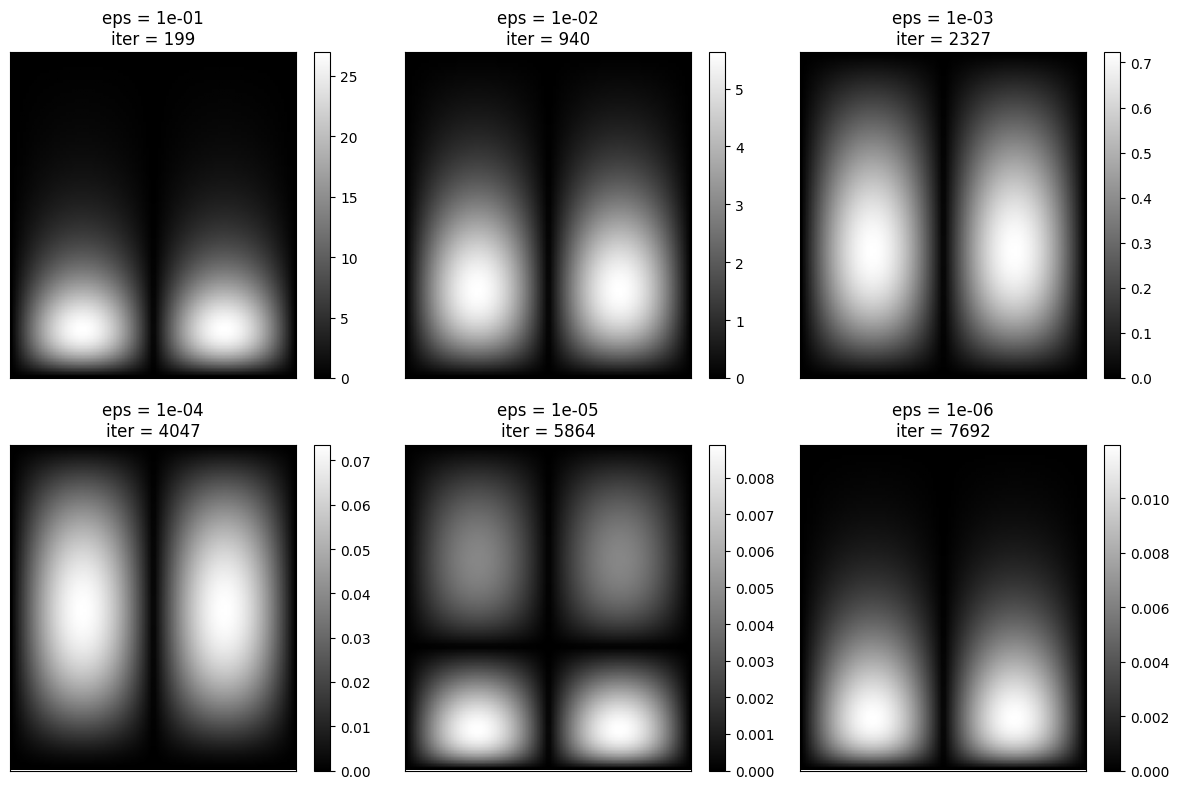

In [22]:
N = 100
delta = 1
L = N*delta # Unidades de pepitas xd.
u0 = 100 # Unidades de pepitos xd.
# Podemos definir nuestra u (en 0's) sin preocuparnos de mayor cosa.
# Bueno, sí hay que tener un cuidado, con el infinito en y
# Podríamos hacer un plano muy largo, tanto que aproximemos el valor superior
# a 0, o podríamos darle el valor analítico... me parece más fino poner el valor
# analitico. Por supuesto, hay casos en los que uno no tiene el valor analítico
# (¿en estos casos ni puedo comparar, no?) podríamos hacer la parte en y muucho
# más larga, hasta que podamos aproximar que la solución numérica se vaya a 0.
# En ese caso tendría que trabajar con espaciados distintos en x y y, pero no es
# muy distinto a lo que ya hemos hecho. Mi punto aquí es que hay formas de abordarlo,
# pero teniendo la sol. analítica, ¿por qué no usarla?
import numpy as np
u = np.zeros((N,N))
# La cuestión viene cuando vamos a definir las condiciones de frontera, aquí hay ser cuidadosos
# Para evaluar en el borde no nulo es necesario definir nuestro plano, al menos la variable involucrada...

k = 2*np.pi/L # Esta es una variable auxiliar para que las funciones no queden tan difíciles de escribir

# Definamos de una vez el plano para graficar
x = np.linspace(0, L, N)
Ny = N
y = x

X, Y = np.meshgrid(x,y)

u[0,:] = u0*np.sin(k*x) # condición de frontera en y=0.
u[-1,:] = u0*np.sin(k*x)*np.exp(-k*L) # Esta es la condición analítica evaluada en el borde superior.

# Aunque no se nos pide, quisiera evaluar la convergencia de la sol. numérica graficando las diferencias con la analítica
# en distintas tolerancias, basta con hacer un ciclo for sobre un array de las tolerancias, calcular la diferencia y graficar 
epsilon = [1e-1,1e-2,1e-3,1e-4,1e-5,1e-6]
fig, axes = plt.subplots(2, 3, figsize=(12,8))
for ax, eps in zip(axes.ravel(), epsilon):
    u_new = u.copy()
    u_old = u.copy()
    count = 0
    while True:
        u_new[-1,:] = u0*np.sin(k*x)*np.exp(-k*L)
        for i in range(1,u.shape[0]-1):
            for j in range(1,u.shape[1]-1):
                u_new[i,j] = .25*(u_old[i+1,j]+u_old[i-1,j]+u_old[i,j+1]+u_old[i,j-1])
        count +=1
        if np.max(np.abs(u_new-u_old))<=eps:
            break
        u_old = u_new.copy()
    err_map = np.abs(u_new - u0*np.sin(k*X)*np.exp(-k*Y))

    im = ax.imshow(err_map, origin="lower", cmap="gray", aspect="auto")

    fig.colorbar(im, ax=ax)
    ax.set_title(f"eps = {eps:.0e}\niter = {count}")
    ax.set_xticks([])
    ax.set_yticks([])

    print(f"para una tolerancia de {eps:.1e} se hicieron {count} iteraciones")
plt.tight_layout()
plt.show()

BIEN... NOTA 5